<a href="https://colab.research.google.com/github/AkhilaSunesh/Epoch_Data_Science_Bootcamp/blob/main/Day2Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2
**Name:** Akhila Sunesh <br>
**Date:** 23rd July 2026 <br>
**Time:** 5:47am


**Dataset:** [Northwind SQLite3](https://github.com/jpwhite3/northwind-SQLite3)  
**Scope:** Sales performance across products, customers, categories and time (2012–2023)

---
## Table of Contents
1. [Setup & Connection](#1-setup)
2. [Query 1 — Top 10 Products](#2-top-products)
3. [Query 2 — Top 10 Customers](#3-top-customers)
4. [Query 3 — Monthly Sales Trends](#4-monthly-trends)
5. [Query 4 — Category Performance](#5-categories)
6. [Query 5 — Purchase Frequency](#6-frequency)
7. [Business Insights Summary](#7-insights)

---
## 1 — Setup & Connection <a id='1-setup'></a>

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os, urllib.request

DB_PATH = 'northwind.db'
DB_URL  = 'https://github.com/jpwhite3/northwind-SQLite3/raw/main/dist/northwind.db'

if not os.path.exists(DB_PATH) or os.path.getsize(DB_PATH) < 1_000_000:
    print('Downloading northwind.db (~24 MB)...')
    urllib.request.urlretrieve(DB_URL, DB_PATH)
else:
    print(f'✅ northwind.db already present')
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = sns.color_palette('Blues_r', 10)

conn = sqlite3.connect('northwind.db')
print('✅ Connected to northwind.db')

cur = conn.cursor()
tables = [r[0] for r in cur.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
).fetchall()]
print(f'Tables ({len(tables)}):', tables)


✅ Connected to northwind.db
Tables (14): ['Categories', 'CustomerCustomerDemo', 'CustomerDemographics', 'Customers', 'EmployeeTerritories', 'Employees', 'Order Details', 'Orders', 'Products', 'Regions', 'Shippers', 'Suppliers', 'Territories', 'sqlite_sequence']


---
## 2 - Top 10 Selling Products by Revenue <a id='2-top-products'></a>

In [6]:
sql_top_products = """
SELECT
    p.ProductID,
    p.ProductName,
    SUM(od.Quantity)                                                 AS TotalUnitsSold,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2)   AS TotalRevenue,
    ROUND(AVG(od.Discount) * 100, 2)                                AS AvgDiscountPct
FROM \"Order Details\" od
JOIN Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductID, p.ProductName
ORDER BY TotalRevenue DESC
LIMIT 10
"""
df_products = pd.read_sql_query(sql_top_products, conn)
df_products['RevenueM'] = df_products['TotalRevenue'] / 1_000_000
df_products

,ProductID,ProductName,TotalUnitsSold,TotalRevenue,AvgDiscountPct,RevenueM
0,38,Côte de Blaye,202234,53265895.24,0.01,53.265895
1,29,Thüringer Rostbratwurst,199010,24623469.23,0.03,24.623469
2,9,Mishi Kobe Niku,200258,19423037.50,0.01,19.423037
3,20,Sir Rodney's Marmalade,205637,16653807.36,0.01,16.653807
4,18,Carnarvon Tigers,201747,12604671.88,0.03,12.604672
5,59,Raclette Courdavault,204137,11216410.70,0.03,11.216411
6,51,Manjimup Dried Apples,201319,10664768.65,0.03,10.664769
7,62,Tarte au sucre,202010,9952936.07,0.03,9.952936
8,43,Ipoh Coffee,202968,9333374.70,0.02,9.333375
9,28,Rössle Sauerkraut,202988,9252765.44,0.02,9.252765


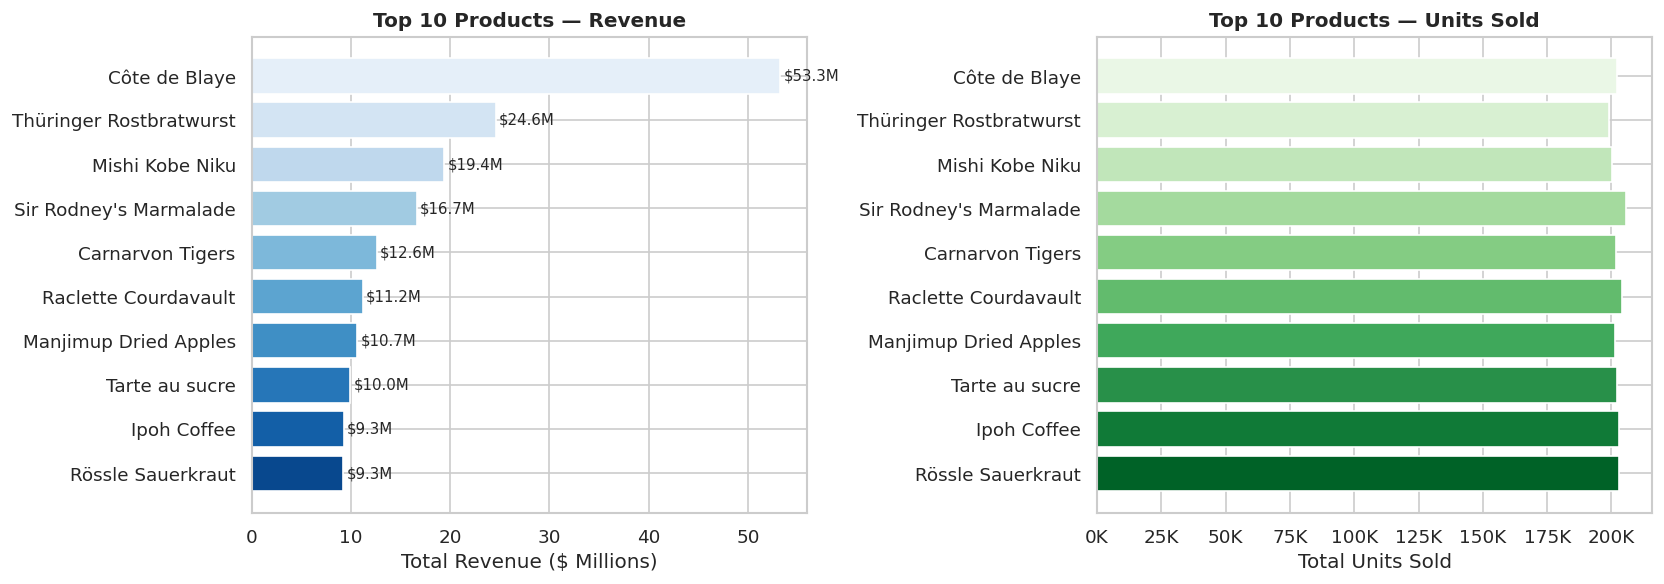

Figure saved → top_products.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue bar
bars = axes[0].barh(df_products['ProductName'][::-1],
                     df_products['RevenueM'][::-1], color=PALETTE)
axes[0].set_xlabel('Total Revenue ($ Millions)')
axes[0].set_title('Top 10 Products — Revenue', fontweight='bold')
for bar, val in zip(bars, df_products['RevenueM'][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'${val:.1f}M', va='center', fontsize=9)

# Units sold bar
bars2 = axes[1].barh(df_products['ProductName'][::-1],
                      df_products['TotalUnitsSold'][::-1],
                      color=sns.color_palette('Greens_r', 10))
axes[1].set_xlabel('Total Units Sold')
axes[1].set_title('Top 10 Products — Units Sold', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('top_products.png', bbox_inches='tight')
plt.show()
print('Figure saved → top_products.png')

---
## 3 - Top 10 Customers by Revenue <a id='3-top-customers'></a>

In [8]:
sql_top_customers = """
SELECT
    c.CustomerID,
    c.CompanyName,
    c.City,
    c.Country,
    COUNT(DISTINCT o.OrderID)                                              AS TotalOrders,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2)         AS TotalRevenue,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) /
          COUNT(DISTINCT o.OrderID), 2)                                   AS AvgOrderValue
FROM Customers c
JOIN Orders o ON c.CustomerID = o.CustomerID
JOIN \"Order Details\" od ON o.OrderID = od.OrderID
GROUP BY c.CustomerID, c.CompanyName, c.City, c.Country
ORDER BY TotalRevenue DESC
LIMIT 10
"""
df_customers = pd.read_sql_query(sql_top_customers, conn)
df_customers['RevenueM'] = df_customers['TotalRevenue'] / 1_000_000
df_customers

,CustomerID,CompanyName,City,Country,TotalOrders,TotalRevenue,AvgOrderValue,RevenueM
0,BSBEV,B's Beverages,London,UK,210,6154115.34,29305.31,6.154115
1,HUNGC,Hungry Coyote Import Store,Elgin,USA,198,5698023.67,28777.90,5.698024
2,RANCH,Rancho grande,Buenos Aires,Argentina,194,5559110.08,28655.21,5.559110
3,GOURL,Gourmet Lanchonetes,Campinas,Brazil,202,5552309.81,27486.68,5.552310
4,ANATR,Ana Trujillo Emparedados y helados,México D.F.,Mexico,195,5534356.65,28381.32,5.534357
5,RICAR,Ricardo Adocicados,Rio de Janeiro,Brazil,203,5524517.31,27214.37,5.524517
6,FOLIG,Folies gourmandes,Lille,France,195,5505502.85,28233.35,5.505503
7,LETSS,Let's Stop N Shop,San Francisco,USA,191,5462198.02,28597.90,5.462198
8,LILAS,LILA-Supermercado,Barquisimeto,Venezuela,203,5437438.34,26785.41,5.437438
9,PRINI,Princesa Isabel Vinhos,Lisboa,Portugal,200,5436770.55,27183.85,5.436771


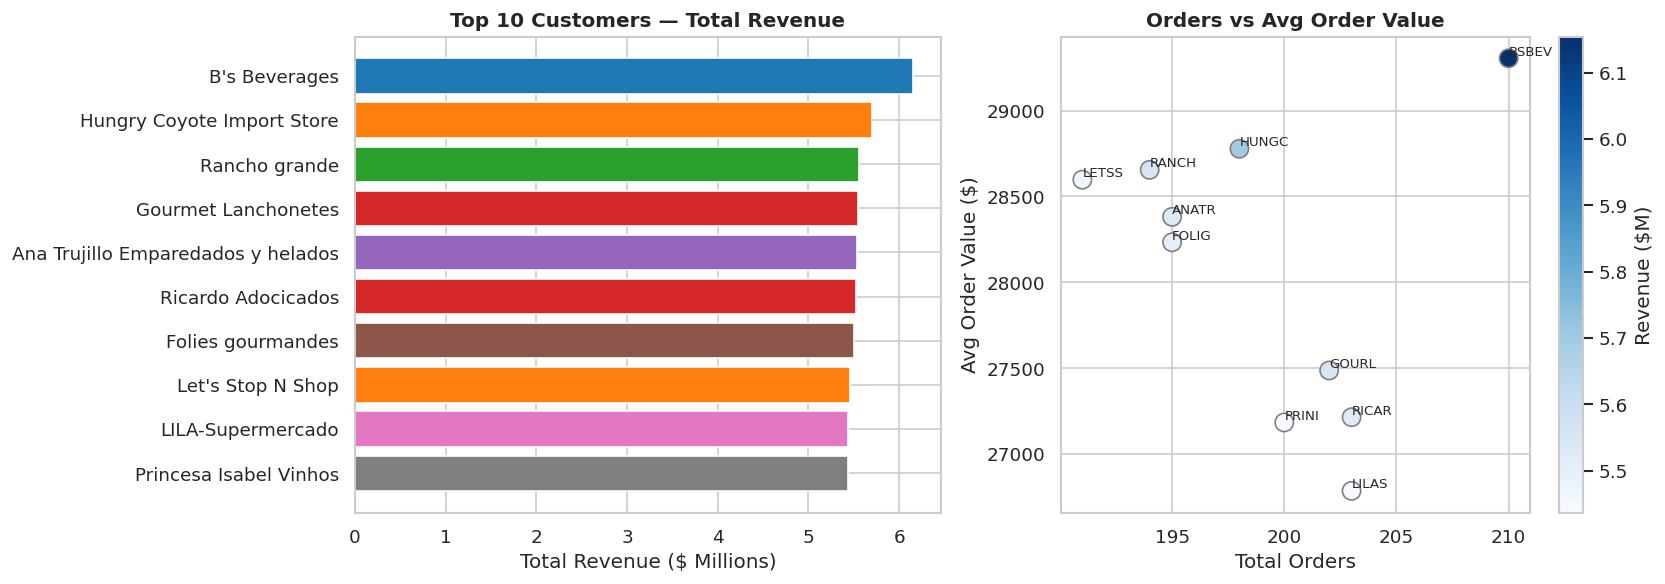

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue
colors_country = sns.color_palette('tab10', df_customers['Country'].nunique())
country_map = {c: colors_country[i] for i, c in enumerate(df_customers['Country'].unique())}
bar_colors = [country_map[c] for c in df_customers['Country'][::-1]]

axes[0].barh(df_customers['CompanyName'][::-1],
             df_customers['RevenueM'][::-1], color=bar_colors)
axes[0].set_xlabel('Total Revenue ($ Millions)')
axes[0].set_title('Top 10 Customers — Total Revenue', fontweight='bold')

# Avg order value scatter
scatter = axes[1].scatter(df_customers['TotalOrders'],
                           df_customers['AvgOrderValue'],
                           c=df_customers['RevenueM'],
                           cmap='Blues', s=120, edgecolors='grey')
for _, row in df_customers.iterrows():
    axes[1].annotate(row['CustomerID'],
                     (row['TotalOrders'], row['AvgOrderValue']),
                     fontsize=8, ha='left', va='bottom')
plt.colorbar(scatter, ax=axes[1], label='Revenue ($M)')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Avg Order Value ($)')
axes[1].set_title('Orders vs Avg Order Value', fontweight='bold')

plt.tight_layout()
plt.savefig('top_customers.png', bbox_inches='tight')
plt.show()

---
## 4 - Monthly Sales Trends <a id='4-monthly-trends'></a>

In [10]:
sql_monthly = """
SELECT
    strftime('%Y-%m', o.OrderDate)                                         AS YearMonth,
    COUNT(DISTINCT o.OrderID)                                              AS TotalOrders,
    COUNT(DISTINCT o.CustomerID)                                           AS UniqueCustomers,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2)         AS MonthlyRevenue,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) /
          COUNT(DISTINCT o.OrderID), 2)                                   AS AvgOrderValue
FROM Orders o
JOIN \"Order Details\" od ON o.OrderID = od.OrderID
WHERE o.OrderDate IS NOT NULL
GROUP BY YearMonth
ORDER BY YearMonth
"""
df_monthly = pd.read_sql_query(sql_monthly, conn)
df_monthly['Date'] = pd.to_datetime(df_monthly['YearMonth'])
df_monthly['RevenueM'] = df_monthly['MonthlyRevenue'] / 1_000_000
df_monthly['Rolling3M'] = df_monthly['RevenueM'].rolling(3).mean()
print(f'Date range: {df_monthly["YearMonth"].min()} → {df_monthly["YearMonth"].max()}')
df_monthly.head()

Date range: 2012-07 → 2023-10


,YearMonth,TotalOrders,UniqueCustomers,MonthlyRevenue,AvgOrderValue,Date,RevenueM,Rolling3M
0,2012-07,69,49,2066219.40,29945.21,2012-07-01,2.066219,NaN
1,2012-08,122,70,3556875.79,29154.72,2012-08-01,3.556876,NaN
2,2012-09,119,72,3440144.98,28908.78,2012-09-01,3.440145,3.021080
3,2012-10,111,66,3201529.96,28842.61,2012-10-01,3.201530,3.399517
4,2012-11,105,65,2980494.74,28385.66,2012-11-01,2.980495,3.207390


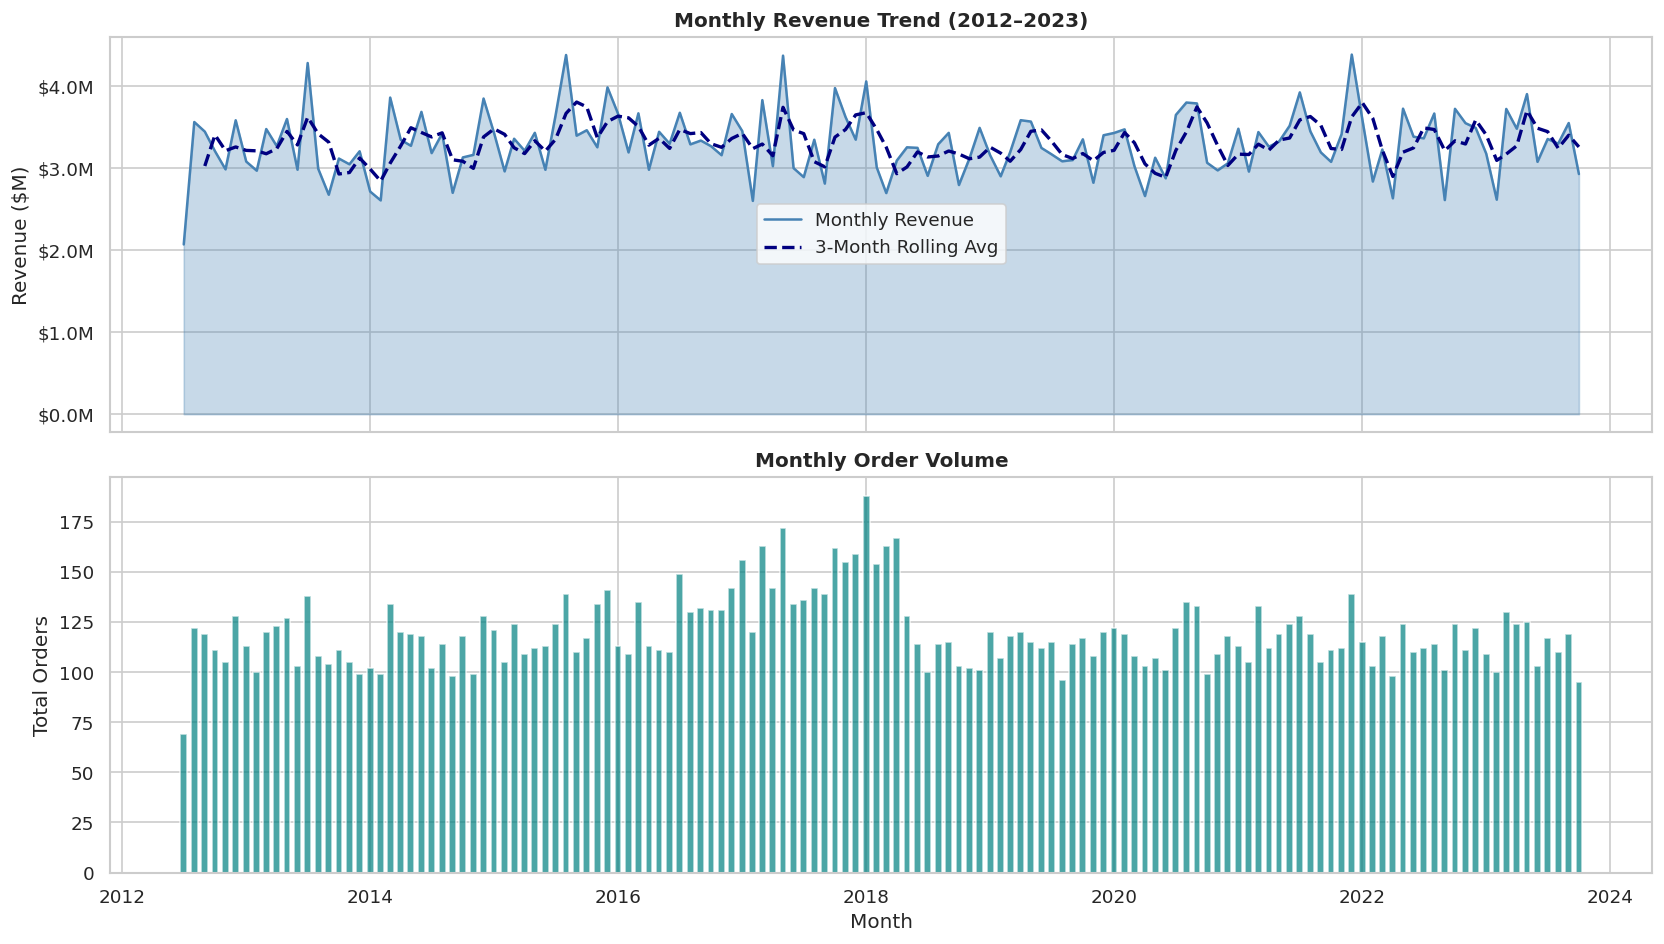

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Revenue
axes[0].fill_between(df_monthly['Date'], df_monthly['RevenueM'],
                      alpha=0.3, color='steelblue')
axes[0].plot(df_monthly['Date'], df_monthly['RevenueM'],
             color='steelblue', lw=1.5, label='Monthly Revenue')
axes[0].plot(df_monthly['Date'], df_monthly['Rolling3M'],
             color='navy', lw=2, ls='--', label='3-Month Rolling Avg')
axes[0].set_ylabel('Revenue ($M)')
axes[0].set_title('Monthly Revenue Trend (2012–2023)', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# Orders
axes[1].bar(df_monthly['Date'], df_monthly['TotalOrders'],
            width=20, color='teal', alpha=0.7)
axes[1].set_ylabel('Total Orders')
axes[1].set_title('Monthly Order Volume', fontweight='bold')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('monthly_trends.png', bbox_inches='tight')
plt.show()

In [12]:
# Year-over-year summary
df_monthly['Year'] = df_monthly['Date'].dt.year
yoy = df_monthly.groupby('Year').agg(
    AnnualRevenue=('MonthlyRevenue', 'sum'),
    TotalOrders=('TotalOrders', 'sum')
).reset_index()
yoy['AnnualRevenue'] = (yoy['AnnualRevenue'] / 1e6).round(2)
yoy['GrowthPct'] = yoy['AnnualRevenue'].pct_change().mul(100).round(1)
yoy.columns = ['Year', 'Annual Revenue ($M)', 'Total Orders', 'YoY Growth (%)']
yoy

,Year,Annual Revenue ($M),Total Orders,YoY Growth (%)
0,2012,18.82,654,NaN
1,2013,38.63,1351,105.3
2,2014,38.87,1351,0.6
3,2015,41.42,1449,6.6
4,2016,40.57,1506,-2.1
5,2017,40.21,1780,-0.9
6,2018,38.33,1549,-4.7
7,2019,38.52,1362,0.5
8,2020,38.86,1376,0.9
9,2021,41.36,1420,6.4


---
## 5 - Best-Performing Product Categories <a id='5-categories'></a>

In [13]:
sql_categories = """
SELECT
    c.CategoryID,
    c.CategoryName,
    COUNT(DISTINCT p.ProductID)                                              AS ProductCount,
    SUM(od.Quantity)                                                         AS TotalUnitsSold,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2)           AS TotalRevenue,
    ROUND(AVG(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2)           AS AvgOrderLineRevenue,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) * 100.0 /
          SUM(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount))) OVER (), 2) AS RevenueSharePct
FROM Categories c
JOIN Products p         ON c.CategoryID  = p.CategoryID
JOIN \"Order Details\" od ON p.ProductID   = od.ProductID
GROUP BY c.CategoryID, c.CategoryName
ORDER BY TotalRevenue DESC
"""
df_categories = pd.read_sql_query(sql_categories, conn)
df_categories['RevenueM'] = (df_categories['TotalRevenue'] / 1e6).round(2)
df_categories

,CategoryID,CategoryName,ProductCount,TotalUnitsSold,TotalRevenue,AvgOrderLineRevenue,RevenueSharePct,RevenueM
0,1,Beverages,12,2427361,92163184.18,969.29,20.55,92.16
1,3,Confections,13,2628466,66337803.07,645.41,14.79,66.34
2,6,Meat/Poultry,6,1207892,64881147.97,1370.68,14.47,64.88
3,4,Dairy Products,10,2020160,58018116.79,732.25,12.94,58.02
4,2,Condiments,12,2420864,55795126.78,587.39,12.44,55.80
5,8,Seafood,12,2410782,49921604.17,525.98,11.13,49.92
6,7,Produce,5,1010224,32701119.88,826.87,7.29,32.70
7,5,Grains/Cereals,7,1412853,28568530.34,515.68,6.37,28.57


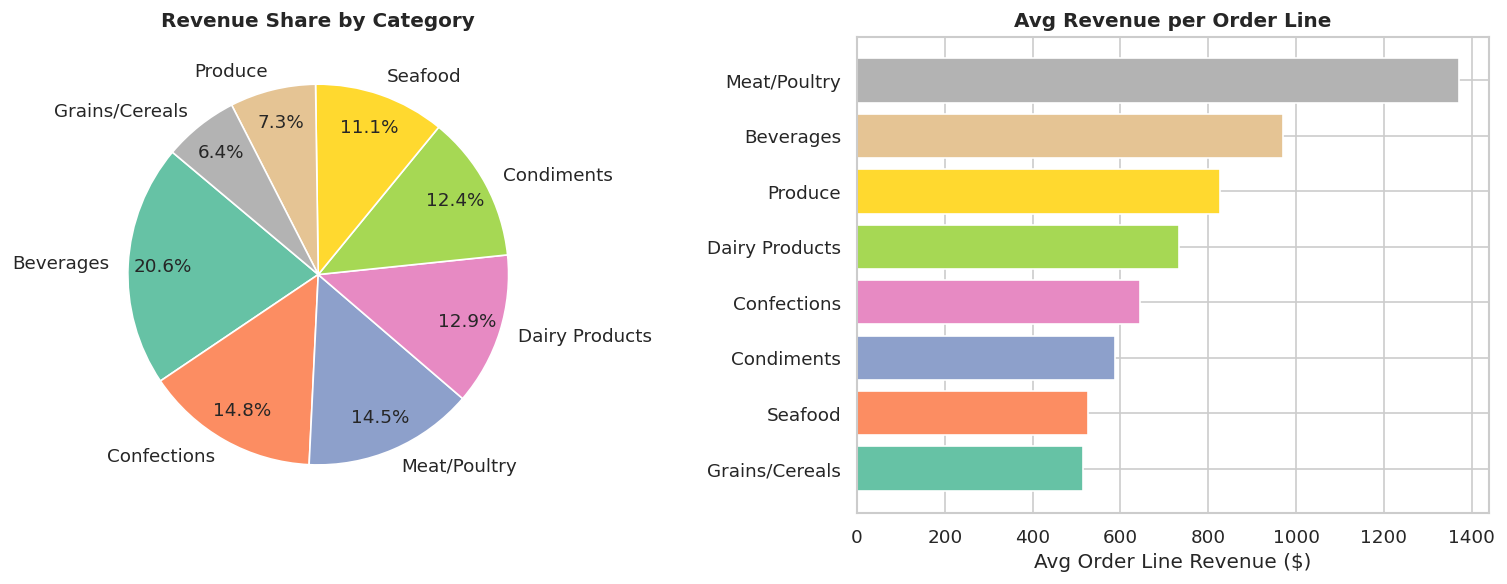

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart — revenue share
wedge_colors = sns.color_palette('Set2', len(df_categories))
axes[0].pie(df_categories['TotalRevenue'],
            labels=df_categories['CategoryName'],
            autopct='%1.1f%%',
            colors=wedge_colors,
            startangle=140,
            pctdistance=0.82)
axes[0].set_title('Revenue Share by Category', fontweight='bold')

# Bar chart — avg order line value
sorted_cat = df_categories.sort_values('AvgOrderLineRevenue', ascending=True)
axes[1].barh(sorted_cat['CategoryName'],
             sorted_cat['AvgOrderLineRevenue'],
             color=sns.color_palette('Set2', len(sorted_cat)))
axes[1].set_xlabel('Avg Order Line Revenue ($)')
axes[1].set_title('Avg Revenue per Order Line', fontweight='bold')

plt.tight_layout()
plt.savefig('category_performance.png', bbox_inches='tight')
plt.show()

---
## 6 - Customer Purchase Frequency <a id='6-frequency'></a>

In [15]:
sql_frequency = """
SELECT
    c.CustomerID,
    c.CompanyName,
    c.Country,
    COUNT(DISTINCT o.OrderID)                                              AS TotalOrders,
    MIN(o.OrderDate)                                                       AS FirstOrder,
    MAX(o.OrderDate)                                                       AS LastOrder,
    ROUND(
        (julianday(MAX(o.OrderDate)) - julianday(MIN(o.OrderDate))) / 30.0
    , 1)                                                                   AS ActiveMonths,
    ROUND(
        CAST(COUNT(DISTINCT o.OrderID) AS FLOAT) /
        ((julianday(MAX(o.OrderDate)) - julianday(MIN(o.OrderDate))) / 30.0 + 1)
    , 2)                                                                   AS OrdersPerMonth
FROM Customers c
JOIN Orders o ON c.CustomerID = o.CustomerID
GROUP BY c.CustomerID, c.CompanyName, c.Country
HAVING TotalOrders > 1
ORDER BY TotalOrders DESC
LIMIT 20
"""
df_freq = pd.read_sql_query(sql_frequency, conn)
df_freq.head(10)

,CustomerID,CompanyName,Country,TotalOrders,FirstOrder,LastOrder,ActiveMonths,OrdersPerMonth
0,BSBEV,B's Beverages,UK,210,2012-08-16 02:52:50,2023-10-18 17:27:12,136.0,1.53
1,LILAS,LILA-Supermercado,Venezuela,203,2012-07-31 21:36:46,2023-10-20 05:26:34,136.6,1.48
2,RICAR,Ricardo Adocicados,Brazil,203,2012-07-10 20:28:57,2023-09-22 13:14:26,136.4,1.48
3,GOURL,Gourmet Lanchonetes,Brazil,202,2012-09-11 00:14:33,2023-10-13 22:45:27,135.0,1.49
4,PRINI,Princesa Isabel Vinhos,Portugal,200,2012-09-13 23:50:37,2023-10-23 06:17:48,135.2,1.47
5,HUNGC,Hungry Coyote Import Store,USA,198,2012-07-29 20:48:41,2023-10-25 02:57:02,136.8,1.44
6,TORTU,Tortuga Restaurante,Mexico,197,2012-07-16 19:32:03,2023-10-17 11:47:50,137.0,1.43
7,ANATR,Ana Trujillo Emparedados y helados,Mexico,195,2012-08-30 11:02:36,2023-10-23 11:35:41,135.7,1.43
8,FOLIG,Folies gourmandes,France,195,2012-07-16 09:41:10,2023-10-15 16:03:36,136.9,1.41
9,RANCH,Rancho grande,Argentina,194,2012-07-12 11:39:39,2023-10-01 22:00:32,136.6,1.41


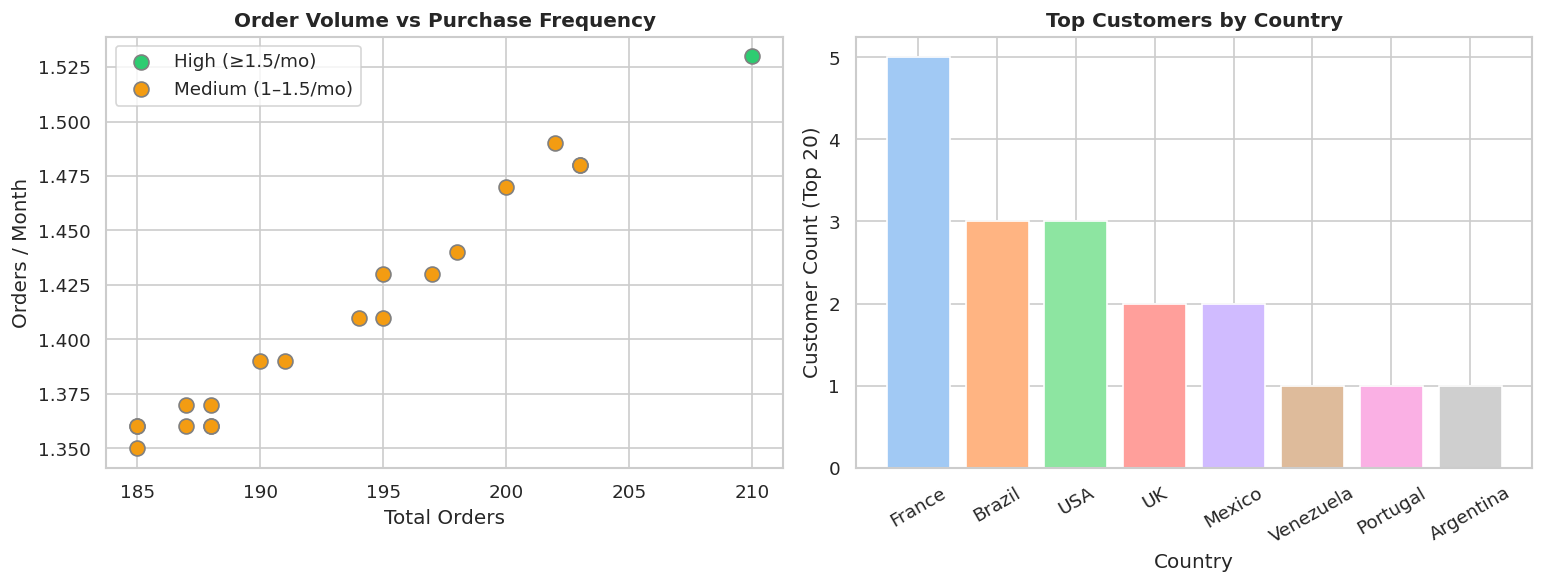

Frequency segment breakdown:
Segment
Medium (1–1.5/mo)    19
High (≥1.5/mo)        1
Name: count, dtype: int64


In [16]:
# Frequency segmentation
def freq_segment(opm):
    if opm >= 1.5:  return 'High (≥1.5/mo)'
    elif opm >= 1:  return 'Medium (1–1.5/mo)'
    else:           return 'Low (<1/mo)'

df_freq['Segment'] = df_freq['OrdersPerMonth'].apply(freq_segment)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter — orders vs frequency
seg_colors = {'High (≥1.5/mo)': '#2ecc71',
              'Medium (1–1.5/mo)': '#f39c12',
              'Low (<1/mo)': '#e74c3c'}
for seg, grp in df_freq.groupby('Segment'):
    axes[0].scatter(grp['TotalOrders'], grp['OrdersPerMonth'],
                    label=seg, color=seg_colors[seg], s=80, edgecolors='grey')
axes[0].set_xlabel('Total Orders')
axes[0].set_ylabel('Orders / Month')
axes[0].set_title('Order Volume vs Purchase Frequency', fontweight='bold')
axes[0].legend()

# Country distribution
country_counts = df_freq['Country'].value_counts().head(8)
axes[1].bar(country_counts.index, country_counts.values,
            color=sns.color_palette('pastel', len(country_counts)))
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Customer Count (Top 20)')
axes[1].set_title('Top Customers by Country', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('purchase_frequency.png', bbox_inches='tight')
plt.show()

print('Frequency segment breakdown:')
print(df_freq['Segment'].value_counts())

---
## 7 - Business Insights Summary <a id='7-insights'></a>



In [19]:
# ── Insight 1: Product revenue concentration ──────────────────
top3_rev   = df_products.head(3)['TotalRevenue'].sum()
total_rev  = pd.read_sql_query(
    'SELECT ROUND(SUM(UnitPrice * Quantity * (1-Discount)),2) AS t FROM "Order Details"', conn
).iloc[0,0]
pct = round(top3_rev / total_rev * 100, 1)

print(f"""INSIGHT 1 — Revenue Concentration Risk
The top 3 products (Côte de Blaye, Thüringer Rostbratwurst, Mishi Kobe Niku)
account for {pct}% of total product revenue (${top3_rev/1e6:.1f}M of ${total_rev/1e6:.1f}M).
This heavy reliance on a small SKU set poses supply and demand risk.
""")

INSIGHT 1 — Revenue Concentration Risk
The top 3 products (Côte de Blaye, Thüringer Rostbratwurst, Mishi Kobe Niku)
account for 21.7% of total product revenue ($97.3M of $448.4M).
This heavy reliance on a small SKU set poses supply and demand risk.



In [20]:
# ── Insight 2: Beverages dominant category ────────────────────
top_cat = df_categories.iloc[0]
print(f"""INSIGHT 2 — Beverages Dominate Category Mix
{top_cat['CategoryName']} is the #1 category with ${top_cat['RevenueM']:.1f}M revenue
({top_cat['RevenueSharePct']}% share) across {top_cat['ProductCount']} SKUs.
Meat/Poultry generates the highest avg order-line value (${df_categories[df_categories.CategoryName=='Meat/Poultry']['AvgOrderLineRevenue'].values[0]:,.0f}),
suggesting a premium-pricing opportunity.
""")

INSIGHT 2 — Beverages Dominate Category Mix
Beverages is the #1 category with $92.2M revenue
(20.55% share) across 12 SKUs.
Meat/Poultry generates the highest avg order-line value ($1,371),
suggesting a premium-pricing opportunity.



In [21]:
# ── Insight 3: High-value customer pareto ─────────────────────
top10_cust_rev = df_customers['TotalRevenue'].sum()
all_cust_rev   = pd.read_sql_query(
    'SELECT ROUND(SUM(od.UnitPrice*od.Quantity*(1-od.Discount)),2) AS t '
    'FROM "Order Details" od', conn
).iloc[0,0]
pct2 = round(top10_cust_rev / all_cust_rev * 100, 1)

print(f"""INSIGHT 3 — Top 10 Customers Drive {pct2}% of Revenue
The 10 highest-spending customers generate ${top10_cust_rev/1e6:.1f}M of total revenue.
Retention programs and dedicated account managers for these accounts
would have an outsized impact on the bottom line.
""")

INSIGHT 3 — Top 10 Customers Drive 12.5% of Revenue
The 10 highest-spending customers generate $55.9M of total revenue.
Retention programs and dedicated account managers for these accounts
would have an outsized impact on the bottom line.



INSIGHT 4 — Seasonal Revenue Peaks in December
Average monthly revenue peaks in December ($3.58M)
and dips in February ($2.92M) — a 23% swing.
Inventory and staffing plans should anticipate this seasonal demand cycle.



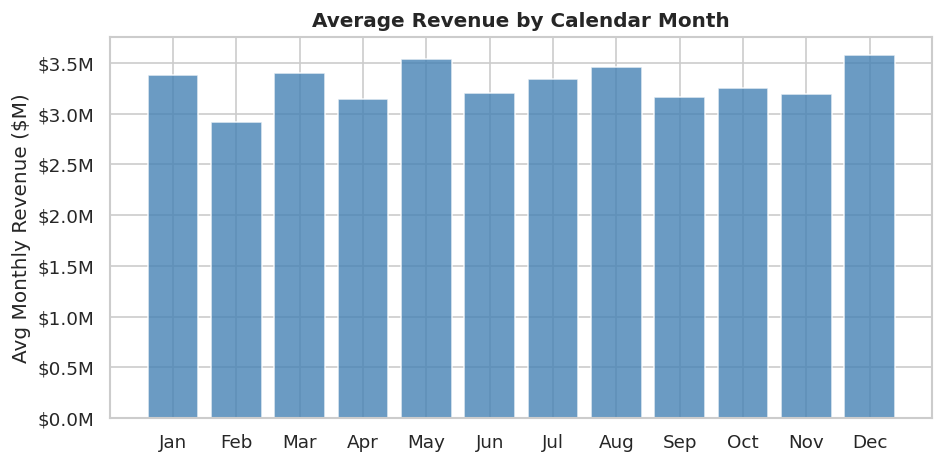

In [23]:
# ── Insight 4: Seasonality / year-end peaks ───────────────────
df_monthly['Month'] = df_monthly['Date'].dt.month
monthly_avg = df_monthly.groupby('Month')['RevenueM'].mean().round(2)
peak_month  = monthly_avg.idxmax()
low_month   = monthly_avg.idxmin()

import calendar
print(f"""INSIGHT 4 — Seasonal Revenue Peaks in {calendar.month_name[peak_month]}
Average monthly revenue peaks in {calendar.month_name[peak_month]} (${monthly_avg[peak_month]:.2f}M)
and dips in {calendar.month_name[low_month]} (${monthly_avg[low_month]:.2f}M) — a {round((monthly_avg[peak_month]/monthly_avg[low_month]-1)*100)}% swing.
Inventory and staffing plans should anticipate this seasonal demand cycle.
""")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([calendar.month_abbr[m] for m in range(1,13)])
ax.set_ylabel('Avg Monthly Revenue ($M)')
ax.set_title('Average Revenue by Calendar Month', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.tight_layout()
plt.savefig('seasonality.png', bbox_inches='tight')
plt.show()

INSIGHT 5 — Customer Loyalty Opportunity
0.0% of customers placed only 1 order — indicating low loyalty or
poor post-purchase engagement. The median customer placed 175 orders.
A re-engagement campaign targeting one-time buyers could meaningfully
increase repeat-purchase rate and customer lifetime value (CLV).



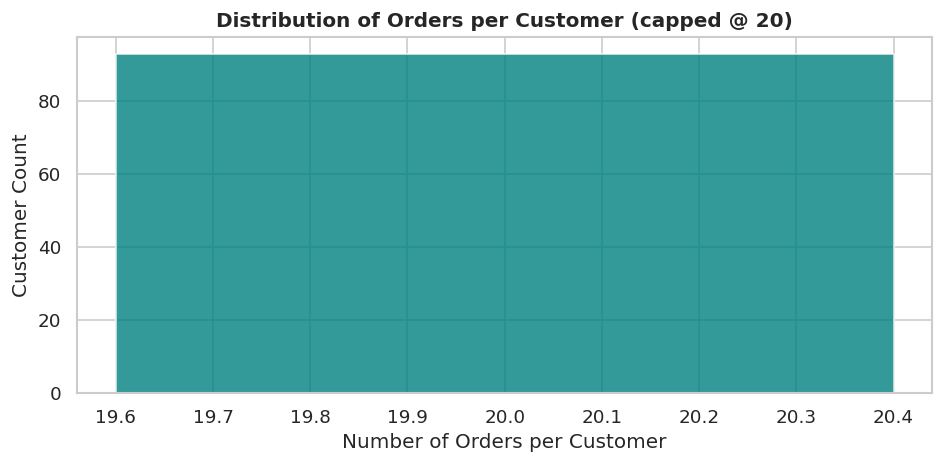

In [24]:
# ── Insight 5: Purchase frequency & loyalty ───────────────────
all_freq = pd.read_sql_query(
    """
    SELECT CustomerID, COUNT(DISTINCT OrderID) AS TotalOrders
    FROM Orders GROUP BY CustomerID
    """, conn
)
single_order_pct = round((all_freq['TotalOrders'] == 1).mean() * 100, 1)
median_orders    = all_freq['TotalOrders'].median()

print(f"""INSIGHT 5 — Customer Loyalty Opportunity
{single_order_pct}% of customers placed only 1 order — indicating low loyalty or
poor post-purchase engagement. The median customer placed {int(median_orders)} orders.
A re-engagement campaign targeting one-time buyers could meaningfully
increase repeat-purchase rate and customer lifetime value (CLV).
""")

fig, ax = plt.subplots(figsize=(8, 4))
order_dist = all_freq['TotalOrders'].clip(upper=20).value_counts().sort_index()
ax.bar(order_dist.index, order_dist.values, color='teal', alpha=0.8)
ax.set_xlabel('Number of Orders per Customer')
ax.set_ylabel('Customer Count')
ax.set_title('Distribution of Orders per Customer (capped @ 20)', fontweight='bold')
plt.tight_layout()
plt.savefig('order_distribution.png', bbox_inches='tight')
plt.show()

In [25]:
conn.close()
print('✅ All analyses complete. Database connection closed.')
print('\nFiles saved:')
import os
for f in ['top_products.png','top_customers.png','monthly_trends.png',
          'category_performance.png','purchase_frequency.png',
          'seasonality.png','order_distribution.png']:
    size = os.path.getsize(f) // 1024 if os.path.exists(f) else 0
    print(f'  {f}  ({size} KB)')

✅ All analyses complete. Database connection closed.

Files saved:
  top_products.png  (73 KB)
  top_customers.png  (100 KB)
  monthly_trends.png  (129 KB)
  category_performance.png  (96 KB)
  purchase_frequency.png  (78 KB)
  seasonality.png  (35 KB)
  order_distribution.png  (29 KB)
